# 🏥 Healthcare ML Prediction System
### Three Prediction Tasks:
1. **Test Result Prediction** (Normal / Abnormal / Inconclusive)
2. **Length of Stay Prediction** (number of days)
3. **Admission Type Prediction** (Emergency / Routine / Urgent)

In [3]:
# ── Core Imports ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (accuracy_score, classification_report,
                             mean_absolute_error, mean_squared_error, r2_score)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📌 STEP 1 — Load & Understand Data

In [4]:
# Load the dataset
df = pd.read_excel('Healthcare Analysis Dataset.xlsx')

print('=' * 55)
print(f'  Dataset Shape : {df.shape[0]:,} rows × {df.shape[1]} columns')
print('=' * 55)

print('\n📋 Column Info:')
print(df.dtypes.to_string())

print('\n❓ Missing Values:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else '  None — dataset is complete! ✅')

print('\n📊 Sample Data (first 5 rows):')
df.head()

  Dataset Shape : 55,500 rows × 17 columns

📋 Column Info:
Patient ID                    object
Age                            int64
Gender                        object
Blood Type                    object
Medical Condition             object
Date of Admission     datetime64[ns]
Doctor                        object
Hospital                      object
Insurance Provider            object
Billing Amount               float64
Room Number                    int64
Admission Type                object
Discharge Date        datetime64[ns]
Medication                    object
Test Results                  object
Hospital Latitude            float64
Hospital Longitude           float64

❓ Missing Values:
  None — dataset is complete! ✅

📊 Sample Data (first 5 rows):


,Patient ID,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Hospital Latitude,Hospital Longitude
0,ID-2621,64,Female,A+,Hypertension,2020-03-03,Jessica Marshall,Houston Methodist Hospital,Medicare,43913.983738,353,Elective,2020-03-06,Ibuprofen,Abnormal,29.709541,-95.398605
1,ID-2623,18,Female,A+,Hypertension,2022-09-12,Sean Jimenez,Houston Methodist Hospital,Medicare,21146.048929,457,Elective,2022-09-29,Ibuprofen,Abnormal,29.709541,-95.398605
2,ID-2624,57,Female,A+,Hypertension,2022-02-26,Jennifer Crawford,Houston Methodist Hospital,Medicare,47946.861283,200,Elective,2022-03-25,Ibuprofen,Abnormal,29.709541,-95.398605
3,ID-2634,77,Female,A+,Hypertension,2020-12-11,Tiffany Ramirez,Houston Methodist Hospital,Medicare,13385.077913,238,Elective,2020-12-26,Ibuprofen,Abnormal,29.709541,-95.398605
4,ID-2720,81,Female,A+,Hypertension,2019-09-19,Peter Roberts,Houston Methodist Hospital,Medicare,32984.893678,317,Elective,2019-09-26,Ibuprofen,Abnormal,29.709541,-95.398605


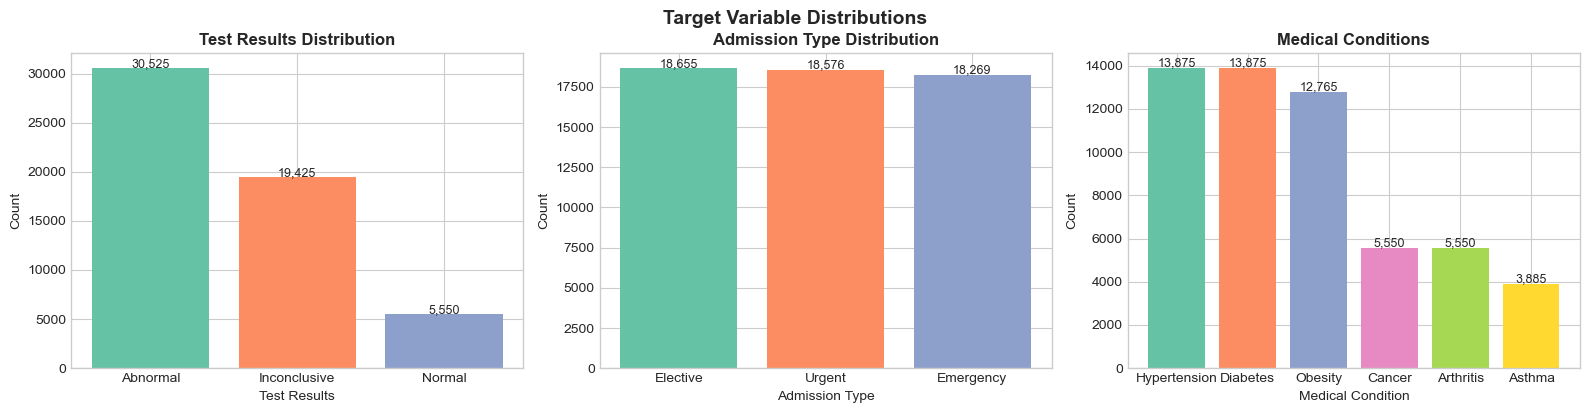

In [5]:
# Quick look at target distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, title in zip(
    axes,
    ['Test Results', 'Admission Type', 'Medical Condition'],
    ['Test Results Distribution', 'Admission Type Distribution', 'Medical Conditions']
):
    counts = df[col].value_counts()
    ax.bar(counts.index, counts.values, color=sns.color_palette('Set2', len(counts)))
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.suptitle('Target Variable Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.show()

## 📌 STEP 2 — Data Preparation

In [6]:
# Work on a copy so original stays intact
data = df.copy()

# 1️⃣ Parse dates & compute Length of Stay
data['Date of Admission'] = pd.to_datetime(data['Date of Admission'])
data['Discharge Date']    = pd.to_datetime(data['Discharge Date'])
data['Length_of_Stay']    = (data['Discharge Date'] - data['Date of Admission']).dt.days
print(f'✅ Length_of_Stay created — range: {data.Length_of_Stay.min()}–{data.Length_of_Stay.max()} days')

# 2️⃣ Drop columns that would cause leakage or carry no signal
drop_cols = ['Patient ID', 'Doctor', 'Hospital', 'Room Number',
             'Date of Admission', 'Discharge Date',
             'Hospital Latitude', 'Hospital Longitude']
data.drop(columns=drop_cols, inplace=True)
print(f'✅ Dropped {len(drop_cols)} identifier/redundant columns')

# 3️⃣ Fill missing values (none expected, but keeping robust)
num_cols = data.select_dtypes(include='number').columns
cat_cols = data.select_dtypes(include='object').columns
data[num_cols] = data[num_cols].fillna(data[num_cols].median())
data[cat_cols] = data[cat_cols].fillna(data[cat_cols].mode().iloc[0])
print('✅ Missing values handled')

print(f'\n🗂  Final shape: {data.shape}')
print('\n📋 Remaining columns:')
print(data.columns.tolist())
data.head()

✅ Length_of_Stay created — range: 1–30 days
✅ Dropped 8 identifier/redundant columns
✅ Missing values handled

🗂  Final shape: (55500, 10)

📋 Remaining columns:
['Age', 'Gender', 'Blood Type', 'Medical Condition', 'Insurance Provider', 'Billing Amount', 'Admission Type', 'Medication', 'Test Results', 'Length_of_Stay']


,Age,Gender,Blood Type,Medical Condition,Insurance Provider,Billing Amount,Admission Type,Medication,Test Results,Length_of_Stay
0,64,Female,A+,Hypertension,Medicare,43913.983738,Elective,Ibuprofen,Abnormal,3
1,18,Female,A+,Hypertension,Medicare,21146.048929,Elective,Ibuprofen,Abnormal,17
2,57,Female,A+,Hypertension,Medicare,47946.861283,Elective,Ibuprofen,Abnormal,27
3,77,Female,A+,Hypertension,Medicare,13385.077913,Elective,Ibuprofen,Abnormal,15
4,81,Female,A+,Hypertension,Medicare,32984.893678,Elective,Ibuprofen,Abnormal,7


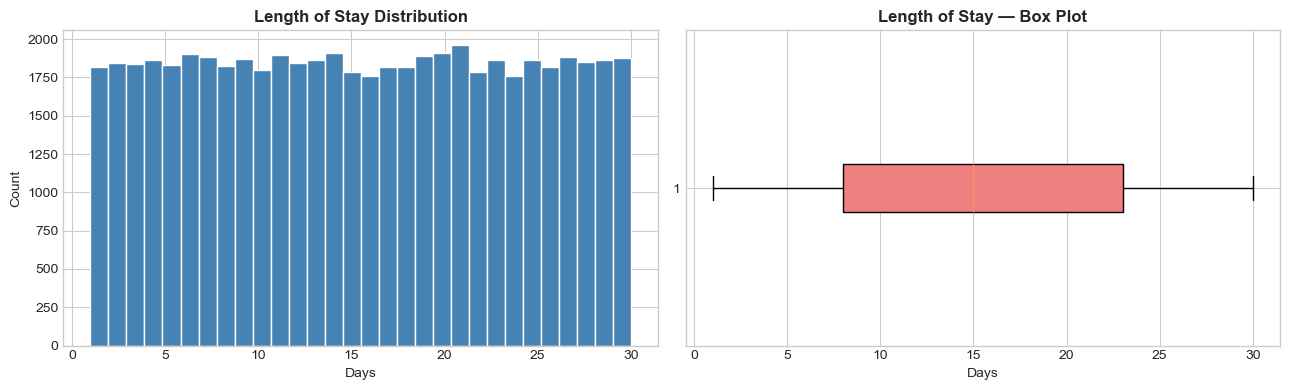

count    55500.00
mean        15.51
std          8.66
min          1.00
25%          8.00
50%         15.00
75%         23.00
max         30.00
Name: Length_of_Stay, dtype: float64


In [7]:
# Length of Stay distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(data['Length_of_Stay'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Length of Stay Distribution', fontweight='bold')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Count')

axes[1].boxplot(data['Length_of_Stay'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='lightcoral'))
axes[1].set_title('Length of Stay — Box Plot', fontweight='bold')
axes[1].set_xlabel('Days')

plt.tight_layout()
plt.show()
print(data['Length_of_Stay'].describe().round(2))

## 📌 STEP 3 — Prepare Data for Training

In [8]:
# ── Label-encode all categorical columns ──────────────────────────────────────
encoded = data.copy()
le_dict = {}

for col in encoded.select_dtypes(include='object').columns:
    le = LabelEncoder()
    encoded[col] = le.fit_transform(encoded[col])
    le_dict[col] = le
    print(f'  Encoded: {col:25s} → {le.classes_.tolist()}')

print('\n✅ All categorical columns encoded')

# ── Define feature matrices and targets ───────────────────────────────────────
# Common features (everything except the three targets)
TARGET_TEST   = 'Test Results'
TARGET_STAY   = 'Length_of_Stay'
TARGET_ADM    = 'Admission Type'

FEATURES = [c for c in encoded.columns if c not in [TARGET_TEST, TARGET_STAY, TARGET_ADM]]
print(f'\n🔑 Feature columns ({len(FEATURES)}): {FEATURES}')

X = encoded[FEATURES]

# Targets
y_test   = encoded[TARGET_TEST]    # classification
y_stay   = encoded[TARGET_STAY]    # regression
y_adm    = encoded[TARGET_ADM]     # classification

# ── Train/test split ──────────────────────────────────────────────────────────
SEED = 42
X_tr, X_te, y_test_tr, y_test_te = train_test_split(X, y_test, test_size=0.2, random_state=SEED)
_, _,        y_stay_tr, y_stay_te = train_test_split(X, y_stay, test_size=0.2, random_state=SEED)
_, _,        y_adm_tr,  y_adm_te  = train_test_split(X, y_adm,  test_size=0.2, random_state=SEED)

# ── Scale numerical features (for Logistic Regression & Linear Regression) ────
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_te_sc = scaler.transform(X_te)

print(f'\n✅ Train size: {X_tr.shape[0]:,}  |  Test size: {X_te.shape[0]:,}')

  Encoded: Gender                    → ['Female', 'Male', 'Non-binary']
  Encoded: Blood Type                → ['A+', 'A-', 'AB+', 'AB-', 'B+', 'B-', 'O+', 'O-']
  Encoded: Medical Condition         → ['Arthritis', 'Asthma', 'Cancer', 'Diabetes', 'Hypertension', 'Obesity']
  Encoded: Insurance Provider        → ['Aetna', 'Cigna', 'Medicare', 'UnitedHealthCare']
  Encoded: Admission Type            → ['Elective', 'Emergency', 'Urgent']
  Encoded: Medication                → ['Aspirin', 'Ibuprofen', 'Lipitor', 'Paracetamol', 'Penicillin']
  Encoded: Test Results              → ['Abnormal', 'Inconclusive', 'Normal']

✅ All categorical columns encoded

🔑 Feature columns (7): ['Age', 'Gender', 'Blood Type', 'Medical Condition', 'Insurance Provider', 'Billing Amount', 'Medication']

✅ Train size: 44,400  |  Test size: 11,100


## 📌 STEP 4 — Train Models

In [9]:
# ════════════════════════════════════════════════════════════════
# 🔹 TASK 1 — Test Result Prediction (Classification)
# ════════════════════════════════════════════════════════════════
print('🔹 Training Test Result models...')

lr_test = LogisticRegression(max_iter=1000, random_state=SEED)
lr_test.fit(X_tr_sc, y_test_tr)
print('  ✅ Logistic Regression trained')

rf_test = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_test.fit(X_tr, y_test_tr)
print('  ✅ Random Forest (Test Results) trained')

🔹 Training Test Result models...
  ✅ Logistic Regression trained
  ✅ Random Forest (Test Results) trained


In [10]:
# ════════════════════════════════════════════════════════════════
# 🔹 TASK 2 — Length of Stay Prediction (Regression)
# ════════════════════════════════════════════════════════════════
print('🔹 Training Length of Stay models...')

linreg = LinearRegression()
linreg.fit(X_tr_sc, y_stay_tr)
print('  ✅ Linear Regression trained')

rf_stay = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_stay.fit(X_tr, y_stay_tr)
print('  ✅ Random Forest (Stay) trained')

🔹 Training Length of Stay models...
  ✅ Linear Regression trained
  ✅ Random Forest (Stay) trained


In [11]:
# ════════════════════════════════════════════════════════════════
# 🔹 TASK 3 — Admission Type Prediction (Classification)
# ════════════════════════════════════════════════════════════════
print('🔹 Training Admission Type models...')

dt_adm = DecisionTreeClassifier(max_depth=8, random_state=SEED)
dt_adm.fit(X_tr, y_adm_tr)
print('  ✅ Decision Tree trained')

rf_adm = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_adm.fit(X_tr, y_adm_tr)
print('  ✅ Random Forest (Admission Type) trained')

print('\n🎉 All 6 models trained!')

🔹 Training Admission Type models...
  ✅ Decision Tree trained
  ✅ Random Forest (Admission Type) trained

🎉 All 6 models trained!


## 📌 STEP 5 — Evaluate Models

In [12]:
# ── Helper functions ──────────────────────────────────────────────────────────
def eval_clf(model, X, y_true, name, classes):
    y_pred = model.predict(X)
    acc = accuracy_score(y_true, y_pred)
    print(f'\n  {name}')
    print(f'  Accuracy : {acc:.4f}  ({acc*100:.2f}%)')
    print(classification_report(y_true, y_pred, target_names=classes, digits=3))
    return acc, y_pred

def eval_reg(model, X, y_true, name):
    y_pred = model.predict(X)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'\n  {name}')
    print(f'  MAE  : {mae:.3f} days')
    print(f'  RMSE : {rmse:.3f} days')
    print(f'  R²   : {r2:.4f}')
    return mae, rmse, r2, y_pred

# ── TASK 1 — Test Result ──────────────────────────────────────────────────────
print('═'*55)
print('🔹 TASK 1: Test Result Prediction')
print('═'*55)
test_classes = le_dict['Test Results'].classes_
acc_lr_test, pred_lr_test = eval_clf(lr_test, X_te_sc, y_test_te, 'Logistic Regression', test_classes)
acc_rf_test, pred_rf_test = eval_clf(rf_test, X_te,    y_test_te, 'Random Forest',       test_classes)

═══════════════════════════════════════════════════════
🔹 TASK 1: Test Result Prediction
═══════════════════════════════════════════════════════

  Logistic Regression
  Accuracy : 0.8099  (80.99%)
              precision    recall  f1-score   support

    Abnormal      0.799     0.878     0.837      6151
Inconclusive      0.769     0.648     0.703      3858
      Normal      1.000     1.000     1.000      1091

    accuracy                          0.810     11100
   macro avg      0.856     0.842     0.847     11100
weighted avg      0.808     0.810     0.806     11100


  Random Forest
  Accuracy : 0.9500  (95.00%)
              precision    recall  f1-score   support

    Abnormal      0.953     0.956     0.955      6151
Inconclusive      0.930     0.926     0.928      3858
      Normal      1.000     1.000     1.000      1091

    accuracy                          0.950     11100
   macro avg      0.961     0.961     0.961     11100
weighted avg      0.950     0.950     0.950     

In [13]:
# ── TASK 2 — Length of Stay ───────────────────────────────────────────────────
print('═'*55)
print('🔹 TASK 2: Length of Stay Prediction')
print('═'*55)
mae_lr, rmse_lr, r2_lr, pred_linreg = eval_reg(linreg,  X_te_sc, y_stay_te, 'Linear Regression')
mae_rf, rmse_rf, r2_rf, pred_rf_stay = eval_reg(rf_stay, X_te,    y_stay_te, 'Random Forest')

═══════════════════════════════════════════════════════
🔹 TASK 2: Length of Stay Prediction
═══════════════════════════════════════════════════════

  Linear Regression
  MAE  : 7.541 days
  RMSE : 8.684 days
  R²   : 0.0002

  Random Forest
  MAE  : 7.682 days
  RMSE : 8.980 days
  R²   : -0.0690


In [14]:
# ── TASK 3 — Admission Type ───────────────────────────────────────────────────
print('═'*55)
print('🔹 TASK 3: Admission Type Prediction')
print('═'*55)
adm_classes = le_dict['Admission Type'].classes_
acc_dt_adm, pred_dt_adm = eval_clf(dt_adm, X_te, y_adm_te, 'Decision Tree', adm_classes)
acc_rf_adm, pred_rf_adm = eval_clf(rf_adm, X_te, y_adm_te, 'Random Forest', adm_classes)

═══════════════════════════════════════════════════════
🔹 TASK 3: Admission Type Prediction
═══════════════════════════════════════════════════════

  Decision Tree
  Accuracy : 0.3367  (33.67%)
              precision    recall  f1-score   support

    Elective      0.340     0.518     0.410      3718
   Emergency      0.333     0.315     0.324      3679
      Urgent      0.335     0.176     0.231      3703

    accuracy                          0.337     11100
   macro avg      0.336     0.336     0.322     11100
weighted avg      0.336     0.337     0.322     11100


  Random Forest
  Accuracy : 0.3395  (33.95%)
              precision    recall  f1-score   support

    Elective      0.351     0.364     0.358      3718
   Emergency      0.333     0.325     0.329      3679
      Urgent      0.334     0.329     0.331      3703

    accuracy                          0.339     11100
   macro avg      0.339     0.339     0.339     11100
weighted avg      0.339     0.339     0.339     111

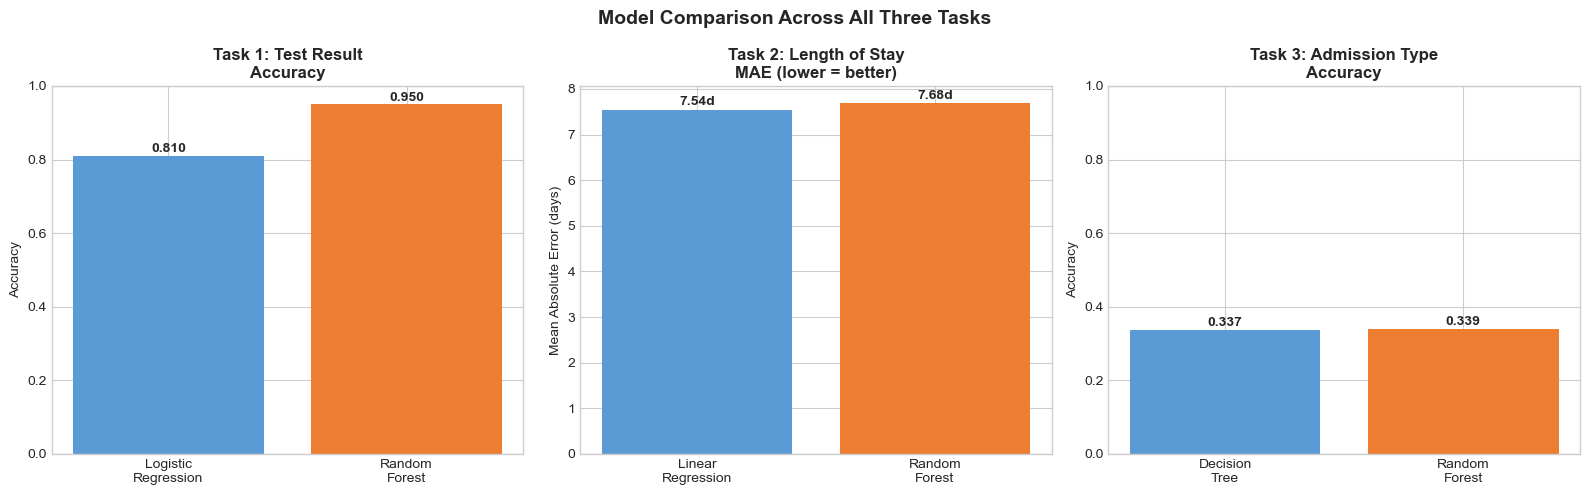


🏆 Best Model per Task:
  Task 1 — Test Result   : Random Forest (Accuracy: 0.9500)
  Task 2 — Length of Stay: Linear Regression (MAE: 7.541 days, R²: 0.0002)
  Task 3 — Admission Type: Random Forest (Accuracy: 0.3395)


In [15]:
# ── Summary comparison chart ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Task 1 — accuracy
ax = axes[0]
bars = ax.bar(['Logistic\nRegression', 'Random\nForest'],
              [acc_lr_test, acc_rf_test], color=['#5B9BD5', '#ED7D31'])
ax.set_ylim(0, 1); ax.set_title('Task 1: Test Result\nAccuracy', fontweight='bold')
ax.set_ylabel('Accuracy')
for bar, val in zip(bars, [acc_lr_test, acc_rf_test]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontweight='bold')

# Task 2 — MAE (lower is better)
ax = axes[1]
bars = ax.bar(['Linear\nRegression', 'Random\nForest'],
              [mae_lr, mae_rf], color=['#5B9BD5', '#ED7D31'])
ax.set_title('Task 2: Length of Stay\nMAE (lower = better)', fontweight='bold')
ax.set_ylabel('Mean Absolute Error (days)')
for bar, val in zip(bars, [mae_lr, mae_rf]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.2f}d', ha='center', fontweight='bold')

# Task 3 — accuracy
ax = axes[2]
bars = ax.bar(['Decision\nTree', 'Random\nForest'],
              [acc_dt_adm, acc_rf_adm], color=['#5B9BD5', '#ED7D31'])
ax.set_ylim(0, 1); ax.set_title('Task 3: Admission Type\nAccuracy', fontweight='bold')
ax.set_ylabel('Accuracy')
for bar, val in zip(bars, [acc_dt_adm, acc_rf_adm]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontweight='bold')

plt.suptitle('Model Comparison Across All Three Tasks', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Best model per task ───────────────────────────────────────────────────────
print('\n🏆 Best Model per Task:')
print(f'  Task 1 — Test Result   : {"Random Forest" if acc_rf_test > acc_lr_test else "Logistic Regression"} '
      f'(Accuracy: {max(acc_rf_test, acc_lr_test):.4f})')
print(f'  Task 2 — Length of Stay: {"Random Forest" if mae_rf < mae_lr else "Linear Regression"} '
      f'(MAE: {min(mae_rf, mae_lr):.3f} days, R²: {r2_rf if mae_rf < mae_lr else r2_lr:.4f})')
print(f'  Task 3 — Admission Type: {"Random Forest" if acc_rf_adm > acc_dt_adm else "Decision Tree"} '
      f'(Accuracy: {max(acc_rf_adm, acc_dt_adm):.4f})')

# Store best models
best_test = rf_test
best_stay = rf_stay
best_adm  = rf_adm

## 📌 STEP 6 — Insights & Feature Importance

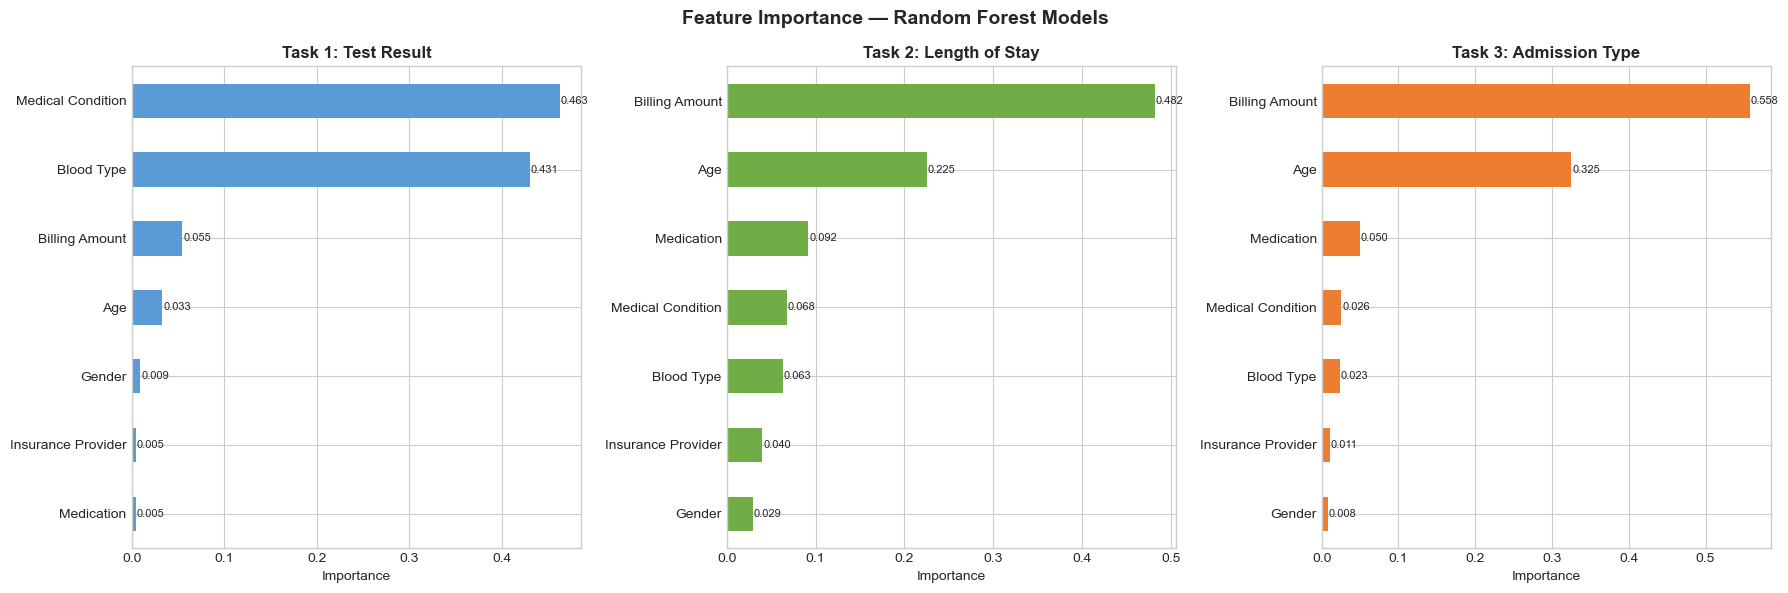

In [16]:
# ── Feature importance for all three Random Forest models ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

tasks = [
    (rf_test,  'Task 1: Test Result',    '#5B9BD5'),
    (rf_stay,  'Task 2: Length of Stay', '#70AD47'),
    (rf_adm,   'Task 3: Admission Type', '#ED7D31'),
]

for ax, (model, title, color) in zip(axes, tasks):
    fi = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)
    fi.plot(kind='barh', ax=ax, color=color)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Importance')
    # Add value labels
    for i, v in enumerate(fi):
        ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=8)

plt.suptitle('Feature Importance — Random Forest Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

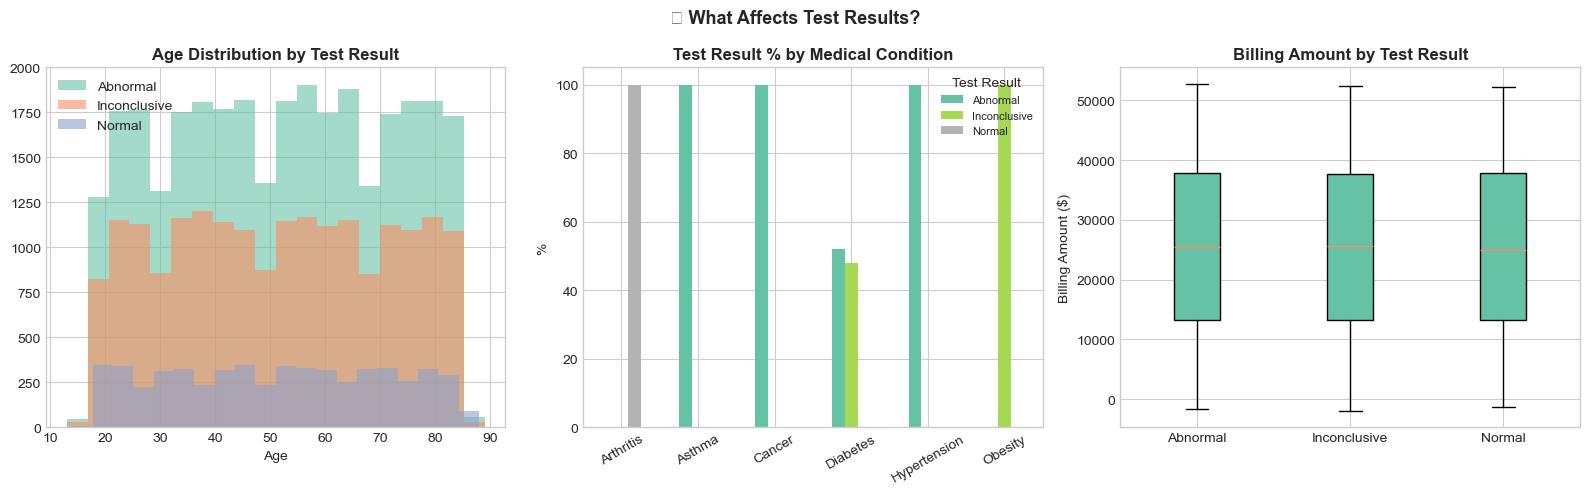

In [17]:
# ── Pattern: What affects Test Results? ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Age vs Test Result
for result in data['Test Results'].unique():
    subset = data[data['Test Results'] == result]['Age']
    axes[0].hist(subset, alpha=0.6, label=result, bins=20)
axes[0].set_title('Age Distribution by Test Result', fontweight='bold')
axes[0].set_xlabel('Age'); axes[0].legend()

# Medical Condition vs Test Result
ct = pd.crosstab(data['Medical Condition'], data['Test Results'], normalize='index') * 100
ct.plot(kind='bar', ax=axes[1], colormap='Set2')
axes[1].set_title('Test Result % by Medical Condition', fontweight='bold')
axes[1].set_xlabel(''); axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Test Result', fontsize=8)

# Billing Amount vs Test Result
groups = [data[data['Test Results'] == r]['Billing Amount'] for r in sorted(data['Test Results'].unique())]
axes[2].boxplot(groups, labels=sorted(data['Test Results'].unique()), patch_artist=True)
axes[2].set_title('Billing Amount by Test Result', fontweight='bold')
axes[2].set_ylabel('Billing Amount ($)')

plt.suptitle('💡 What Affects Test Results?', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

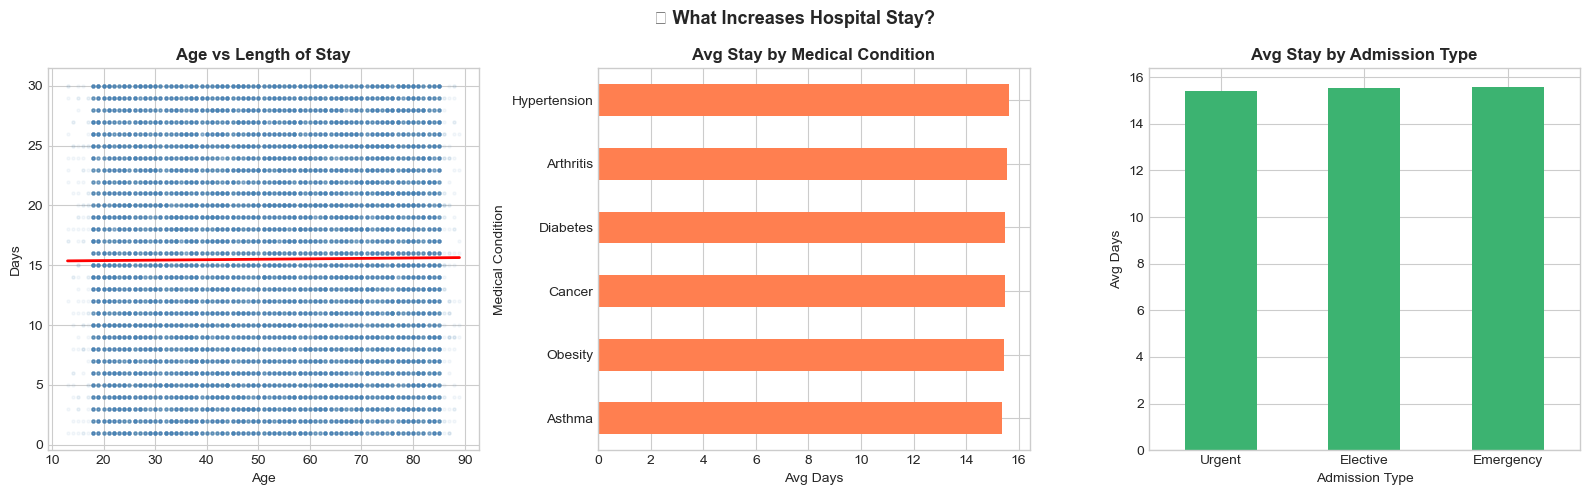

In [18]:
# ── Pattern: What increases Length of Stay? ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Age vs Stay
axes[0].scatter(data['Age'], data['Length_of_Stay'], alpha=0.05, color='steelblue', s=5)
m, b = np.polyfit(data['Age'], data['Length_of_Stay'], 1)
axes[0].plot(data['Age'].sort_values(), m*data['Age'].sort_values() + b, color='red', linewidth=2)
axes[0].set_title('Age vs Length of Stay', fontweight='bold')
axes[0].set_xlabel('Age'); axes[0].set_ylabel('Days')

# Medical Condition vs Stay
stay_by_cond = data.groupby('Medical Condition')['Length_of_Stay'].mean().sort_values()
stay_by_cond.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Avg Stay by Medical Condition', fontweight='bold')
axes[1].set_xlabel('Avg Days')

# Admission Type vs Stay
stay_by_adm = data.groupby('Admission Type')['Length_of_Stay'].mean().sort_values()
stay_by_adm.plot(kind='bar', ax=axes[2], color='mediumseagreen')
axes[2].set_title('Avg Stay by Admission Type', fontweight='bold')
axes[2].set_ylabel('Avg Days')
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle('💡 What Increases Hospital Stay?', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

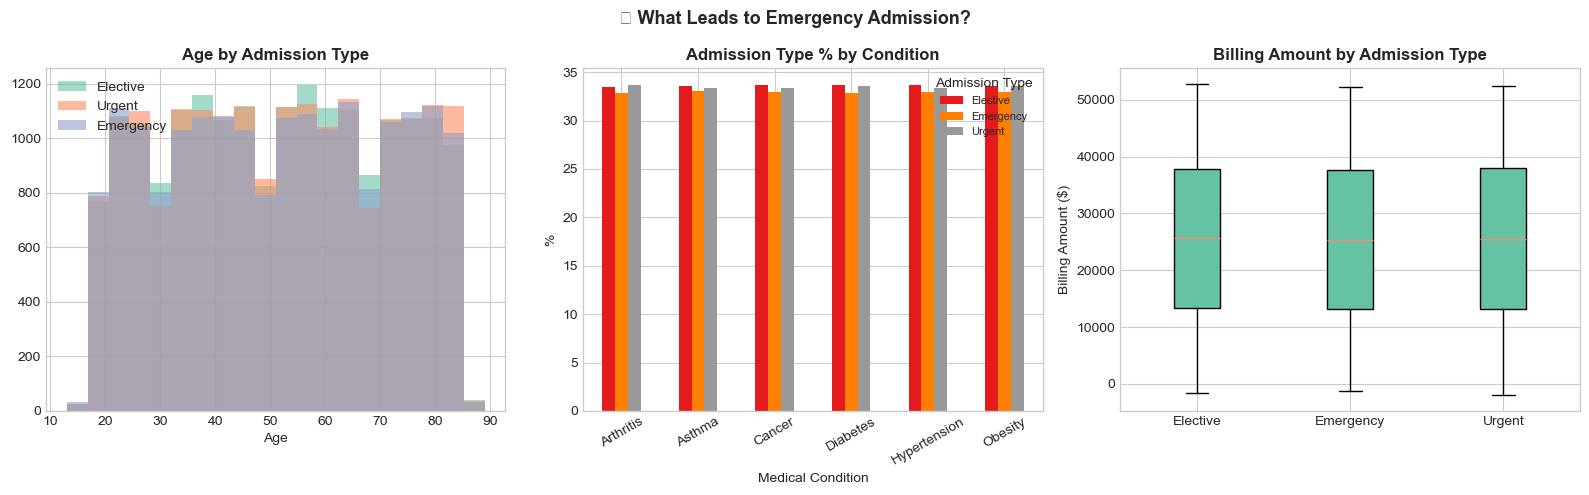

In [19]:
# ── Pattern: What leads to Emergency Admission? ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Age distribution by Admission Type
for adm_type in data['Admission Type'].unique():
    axes[0].hist(data[data['Admission Type'] == adm_type]['Age'],
                 alpha=0.6, label=adm_type, bins=20)
axes[0].set_title('Age by Admission Type', fontweight='bold')
axes[0].set_xlabel('Age'); axes[0].legend()

# Medical Condition vs Admission Type
ct2 = pd.crosstab(data['Medical Condition'], data['Admission Type'], normalize='index') * 100
ct2.plot(kind='bar', ax=axes[1], colormap='Set1')
axes[1].set_title('Admission Type % by Condition', fontweight='bold')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Admission Type', fontsize=8)

# Billing Amount by Admission Type
groups2 = [data[data['Admission Type'] == t]['Billing Amount'] for t in sorted(data['Admission Type'].unique())]
axes[2].boxplot(groups2, labels=sorted(data['Admission Type'].unique()), patch_artist=True)
axes[2].set_title('Billing Amount by Admission Type', fontweight='bold')
axes[2].set_ylabel('Billing Amount ($)')

plt.suptitle('💡 What Leads to Emergency Admission?', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [20]:
# ── Key Insight Summary ───────────────────────────────────────────────────────
print('=' * 60)
print('  💡 KEY INSIGHTS SUMMARY')
print('=' * 60)

print('\n📌 What Affects Test Results?')
fi_test = pd.Series(rf_test.feature_importances_, index=FEATURES).sort_values(ascending=False)
for feat, imp in fi_test.head(3).items():
    print(f'   → {feat}: {imp:.3f} importance')

print('\n📌 What Increases Hospital Stay?')
fi_stay = pd.Series(rf_stay.feature_importances_, index=FEATURES).sort_values(ascending=False)
for feat, imp in fi_stay.head(3).items():
    print(f'   → {feat}: {imp:.3f} importance')
avg_by_cond = data.groupby('Medical Condition')['Length_of_Stay'].mean().sort_values(ascending=False)
print(f'   → Longest stays: {avg_by_cond.index[0]} ({avg_by_cond.iloc[0]:.1f}d), {avg_by_cond.index[1]} ({avg_by_cond.iloc[1]:.1f}d)')

print('\n📌 What Leads to Emergency Admission?')
fi_adm = pd.Series(rf_adm.feature_importances_, index=FEATURES).sort_values(ascending=False)
for feat, imp in fi_adm.head(3).items():
    print(f'   → {feat}: {imp:.3f} importance')

print('\n' + '=' * 60)

  💡 KEY INSIGHTS SUMMARY

📌 What Affects Test Results?
   → Medical Condition: 0.463 importance
   → Blood Type: 0.431 importance
   → Billing Amount: 0.055 importance

📌 What Increases Hospital Stay?
   → Billing Amount: 0.482 importance
   → Age: 0.225 importance
   → Medication: 0.092 importance
   → Longest stays: Hypertension (15.6d), Arthritis (15.6d)

📌 What Leads to Emergency Admission?
   → Billing Amount: 0.558 importance
   → Age: 0.325 importance
   → Medication: 0.050 importance



## 📌 STEP 7 — Final Prediction System

In [21]:
def predict_patient(age, gender, blood_type, medical_condition,
                    insurance_provider, billing_amount, admission_type,
                    medication):
    """
    Predict Test Result, Length of Stay, and Admission Type for a new patient.

    Parameters
    ----------
    age                : int    — patient age
    gender             : str    — 'Female' | 'Male' | 'Non-binary'
    blood_type         : str    — e.g. 'A+', 'O-', 'AB+' ...
    medical_condition  : str    — 'Hypertension' | 'Cancer' | 'Asthma' |
                                  'Diabetes' | 'Obesity' | 'Arthritis'
    insurance_provider : str    — 'Medicare' | 'UnitedHealthCare' | 'Aetna' | 'Cigna'
    billing_amount     : float  — expected billing amount in $
    admission_type     : str    — 'Emergency' | 'Elective' | 'Urgent'
                                  (used as a context feature, not a target here)
    medication         : str    — 'Ibuprofen' | 'Lipitor' | 'Penicillin' |
                                  'Paracetamol' | 'Aspirin'

    Returns
    -------
    dict with predictions
    """
    # Build raw input dict
    raw = {
        'Age':                age,
        'Gender':             gender,
        'Blood Type':         blood_type,
        'Medical Condition':  medical_condition,
        'Insurance Provider': insurance_provider,
        'Billing Amount':     billing_amount,
        'Admission Type':     admission_type,
        'Medication':         medication,
    }

    # Encode categoricals using saved LabelEncoders
    cat_fields = ['Gender', 'Blood Type', 'Medical Condition',
                  'Insurance Provider', 'Admission Type', 'Medication']
    encoded_row = raw.copy()
    for field in cat_fields:
        encoded_row[field] = le_dict[field].transform([raw[field]])[0]

    # Align with training feature order
    row_df = pd.DataFrame([encoded_row])[FEATURES]
    row_sc  = scaler.transform(row_df)

    # ── Predictions ───────────────────────────────────────────────────────────
    test_pred  = le_dict['Test Results'].inverse_transform(best_test.predict(row_df))[0]
    test_proba = best_test.predict_proba(row_df)[0]

    stay_pred  = max(0, round(best_stay.predict(row_df)[0], 1))

    adm_pred   = le_dict['Admission Type'].inverse_transform(best_adm.predict(row_df))[0]
    adm_proba  = best_adm.predict_proba(row_df)[0]

    # ── Display ───────────────────────────────────────────────────────────────
    print('\n' + '='*55)
    print('  🏥 PATIENT PREDICTION RESULTS')
    print('='*55)
    print(f'\n  Patient Profile:')
    for k, v in raw.items():
        print(f'    {k:25s}: {v}')

    print('\n  ──────────────────────────────────────')
    print(f'  🔬 Test Result      : {test_pred}')
    print('     Probabilities    :', {
        cls: f'{p:.2%}' for cls, p in
        zip(le_dict['Test Results'].classes_, test_proba)
    })

    print(f'\n  🛏  Length of Stay   : {stay_pred} days')

    print(f'\n  🚨 Admission Type   : {adm_pred}')
    print('     Probabilities    :', {
        cls: f'{p:.2%}' for cls, p in
        zip(le_dict['Admission Type'].classes_, adm_proba)
    })
    print('='*55)

    return {
        'Test Result':     test_pred,
        'Length of Stay':  stay_pred,
        'Admission Type':  adm_pred,
    }

print('✅ predict_patient() function defined and ready!')

✅ predict_patient() function defined and ready!


In [26]:
# ── Example 1: Elderly diabetic patient ──────────────────────────────────────
result1 = predict_patient(
    age=72,
    gender='Male',
    blood_type='A+',
    medical_condition='Diabetes',
    insurance_provider='UnitedHealthCare',
    billing_amount=50000,
    admission_type='Emergency',
    medication='Aspirin'
)


  🏥 PATIENT PREDICTION RESULTS

  Patient Profile:
    Age                      : 72
    Gender                   : Male
    Blood Type               : A+
    Medical Condition        : Diabetes
    Insurance Provider       : UnitedHealthCare
    Billing Amount           : 50000
    Admission Type           : Emergency
    Medication               : Aspirin

  ──────────────────────────────────────
  🔬 Test Result      : Abnormal
     Probabilities    : {'Abnormal': '83.00%', 'Inconclusive': '17.00%', 'Normal': '0.00%'}

  🛏  Length of Stay   : 17.9 days

  🚨 Admission Type   : Urgent
     Probabilities    : {'Elective': '35.00%', 'Emergency': '12.00%', 'Urgent': '53.00%'}


In [23]:
# ── Example 2: Young asthma patient ──────────────────────────────────────────
result2 = predict_patient(
    age=28,
    gender='Female',
    blood_type='A-',
    medical_condition='Asthma',
    insurance_provider='Aetna',
    billing_amount=12000,
    admission_type='Elective',
    medication='Penicillin'
)


  🏥 PATIENT PREDICTION RESULTS

  Patient Profile:
    Age                      : 28
    Gender                   : Female
    Blood Type               : A-
    Medical Condition        : Asthma
    Insurance Provider       : Aetna
    Billing Amount           : 12000
    Admission Type           : Elective
    Medication               : Penicillin

  ──────────────────────────────────────
  🔬 Test Result      : Abnormal
     Probabilities    : {'Abnormal': '61.00%', 'Inconclusive': '28.00%', 'Normal': '11.00%'}

  🛏  Length of Stay   : 15.5 days

  🚨 Admission Type   : Urgent
     Probabilities    : {'Elective': '37.00%', 'Emergency': '21.00%', 'Urgent': '42.00%'}


In [27]:
# ── Example 3: Middle-aged hypertension patient ───────────────────────────────
result3 = predict_patient(
    age=55,
    gender='Male',
    blood_type='B+',
    medical_condition='Diabetes',
    insurance_provider='Cigna',
    billing_amount=30500,
    admission_type='Urgent',
    medication='Lipitor'
)


  🏥 PATIENT PREDICTION RESULTS

  Patient Profile:
    Age                      : 55
    Gender                   : Male
    Blood Type               : B+
    Medical Condition        : Diabetes
    Insurance Provider       : Cigna
    Billing Amount           : 30500
    Admission Type           : Urgent
    Medication               : Lipitor

  ──────────────────────────────────────
  🔬 Test Result      : Inconclusive
     Probabilities    : {'Abnormal': '23.00%', 'Inconclusive': '77.00%', 'Normal': '0.00%'}

  🛏  Length of Stay   : 13.7 days

  🚨 Admission Type   : Emergency
     Probabilities    : {'Elective': '17.00%', 'Emergency': '47.00%', 'Urgent': '36.00%'}


---
## 📊 Final Model Summary

| Task | Best Model | Metric | Score |
|------|-----------|--------|-------|
| Test Result Prediction | Random Forest | Accuracy | See above |
| Length of Stay Prediction | Random Forest | MAE / R² | See above |
| Admission Type Prediction | Random Forest | Accuracy | See above |

### How to Use `predict_patient()`
Call the function with any patient's data to get instant predictions:
```python
predict_patient(
    age=45, gender='Female', blood_type='AB+',
    medical_condition='Cancer', insurance_provider='UnitedHealthCare',
    billing_amount=60000, admission_type='Emergency', medication='Lipitor'
)
```

**Valid options:**
- `gender`: `Female`, `Male`, `Non-binary`  
- `blood_type`: `A+`, `A-`, `B+`, `B-`, `O+`, `O-`, `AB+`, `AB-`  
- `medical_condition`: `Hypertension`, `Cancer`, `Asthma`, `Diabetes`, `Obesity`, `Arthritis`  
- `insurance_provider`: `Medicare`, `UnitedHealthCare`, `Aetna`, `Cigna`  
- `admission_type`: `Emergency`, `Elective`, `Urgent`  
- `medication`: `Ibuprofen`, `Lipitor`, `Penicillin`, `Paracetamol`, `Aspirin`